In [1]:
## 2026.08.14 LLY: CODEX HCC counterpart of Xenium_lung/histology_derived_niche_index.ipynb
##            TLS / SRI / TNI from StarDist Level-2 softmax on s4769 matched nuclei
##            Helpers: code/CODEX_hcc/hcc_histology_derived_niche_index.py


## 1. Load predicted cell-type probabilities (soft abundance)

This notebook is the **CODEX HCC (s4769)** analog of `Xenium_lung/histology_derived_niche_index.ipynb`.

It uses the **pooled StarDist / matched-AUROC** predictions under `result_all_spatial/stardist/{matched_he}/`.

| Source | Predictions | Coordinates | Use case |
|--------|-------------|-------------|----------|
| **Matched AUROC** (§1–§6) | `stardist/{matched_he}/validation_external_stardist_matched_AUROC.csv` | `HE/{matched_he}/{matched_he}_matched_features_stardist.h5ad` (`obsm['spatial_HE']`) | GT-matched nuclei, clinical comparison |

**Demo region:** `awy-98938_aligned_0d535a74`. Cohort = annotated aligned regions (`Annotation=='Y'`, typically 36).

HCC Level-2 classes (12): B cells, CD4 T, CD8 T, DC, Endothelial, Epithelium (INOS+/−), Fibroblasts, INFg+, Macrophages, Macrophages M2-like, Neutrophils.

Key helpers live in `hcc_histology_derived_niche_index.py` (HCC compartments) and reuse spatial/plot utilities from `histology_derived_niche_index.py`.


In [2]:
import sys
import importlib
from pathlib import Path

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/lingyu/ssd2/Python/"
_repo = Path(f"{path}Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung", _repo / "CODEX_hcc"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import hcc_histology_derived_niche_index as hcc_ni
importlib.reload(hcc_ni)

DATA_ROOT = hcc_ni.DEFAULT_DATA_ROOT
HE_ROOT = hcc_ni.DEFAULT_HE_ROOT
STARDIST_ROOT = hcc_ni.DEFAULT_STARDIST_ROOT
CLINICAL_XLSX = hcc_ni.DEFAULT_CLINICAL_XLSX
OUT_DIR = DATA_ROOT / "result_all_spatial" / "niche_index"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("STARDIST :", STARDIST_ROOT)
print("OUT_DIR  :", OUT_DIR)


DATA_ROOT: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769
STARDIST : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist
OUT_DIR  : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/niche_index


In [3]:
SAMPLE = hcc_ni.DEFAULT_DEMO_SAMPLE
RADIUS_UM = hcc_ni.DEFAULT_HCC_SPATIAL_RADIUS_UM    # 55.0 μm
UM_PER_PX = hcc_ni.DEFAULT_HCC_UM_PER_HE_PIXEL      # 0.5 μm/px

clinical = hcc_ni.load_hcc_clinical_info(CLINICAL_XLSX, sheet_name=hcc_ni.DEFAULT_CLINICAL_SHEET)
annotation = hcc_ni.load_hcc_annotation()
ALL_SAMPLES = hcc_ni.discover_hcc_spatial_samples(clinical, require_h5ad=True)
paths = hcc_ni.hcc_spatial_paths(SAMPLE)

print(f"Demo region: {SAMPLE}")
print(f"Annotated regions with AUROC+h5ad: {len(ALL_SAMPLES)}")
print("AUROC:", paths.auroc_csv)
print("h5ad :", paths.stardist_h5ad)
print(f"Spatial radius: {RADIUS_UM} μm | μm/px={UM_PER_PX} (override if HE scale is calibrated)")
display(hcc_ni.index_formula_table())
display(annotation)
display(clinical.head())


Clinical sheet rows: 50
Retained rows      : 36


,matched_he,region_id,region_label,region_label,patient_id,diagnosis,Response,treatment,tissue_type,tissue_subtype,Visium,Annotation
0,awy-98938_aligned_0d535a74,FinalLiv-27_c001_v001_r001_reg001,70_2,70_2,85557,Pre,Responder,List A,Liver,Primary,N,Y
1,awy-98938_aligned_8ded610e,FinalLiv-27_c001_v001_r001_reg002,70_3,70_3,85557,Pre,Responder,List A,Liver,Primary,N,Y
2,awy-98938_aligned_a5afeef9,FinalLiv-27_c001_v001_r001_reg003,70_4,70_4,85557,Post,Responder,List A,Liver,Primary,N,Y
3,awy-98938_aligned_59f27598,FinalLiv-27_c001_v001_r001_reg004,70_5,70_5,85557,Post,Responder,List A,Liver,Primary,N,Y
4,nwn-95916_aligned_d1ec33a2,FinalLiv-27_c001_v001_r001_reg005,71_2,71_2,85558,Pre,Responder,List A,Liver,Primary,Y,Y
5,nwn-95916_aligned_b16cf712,FinalLiv-27_c001_v001_r001_reg006,71_3,71_3,85558,Pre,Responder,List A,Liver,Primary,Y,Y
6,nwn-95916_aligned_459f2ffd,FinalLiv-27_c001_v001_r001_reg007,71_4,71_4,85558,Post,Responder,List A,Liver,Primary,N,Y
7,nwn-95916_aligned_737dafc9,FinalLiv-27_c001_v001_r001_reg008,71_5,71_5,85558,Post,Responder,List A,Liver,Primary,N,Y
8,dpn-56105_aligned_b32cf147,FinalLiv-27_c001_v001_r001_reg009,72_2,72_2,85559,Pre,Non_Responder,List A,Liver,Primary,Y,Y
9,dpn-56105_aligned_d24763ad,FinalLiv-27_c001_v001_r001_reg010,72_3,72_3,85559,Pre,Non_Responder,List A,Liver,Primary,Y,Y



diagnosis


diagnosis
Pre     18
Post    18
Name: count, dtype: int64


Response


...

Annotation
Y    36
Name: count, dtype: int64

Demo region: awy-98938_aligned_0d535a74
Annotated regions with AUROC+h5ad: 36
AUROC: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/result_all_spatial/stardist/awy-98938_aligned_0d535a74/validation_external_stardist_matched_AUROC.csv
h5ad : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features_stardist.h5ad
Spatial radius: 55.0 μm | μm/px=0.5 (override if HE scale is calibrated)


,index,lung_analog,formula
0,TLS,TLS,sum(B cells + CD4 T + CD8 T + DC)
1,TLS_spatial,TLS_spatial,(B_local × T_local × DC_local)^(1/3) within ra...
2,SRI_ratio,ARI_ratio,Fibroblasts / (Epithelium INOS+ + INOS-)
3,SRI_spatial,ARI_spatial,Fib_local / Epi_local within radius R μm
4,TNI_ratio,FRI_ratio,(Fibroblasts + M2-like macrophages + Endotheli...
5,TNI_spatial,FRI_spatial,(Fib_local × M2_local × Endo_local)^(1/3) / Ep...


,celltype_level2,celltype_level1,celltype_level0
0,Fibroblasts,Stromal,Stromal
1,CD8 T cells,T cells,Immune
2,Macrophages,Myeloid,Immune
3,INFg+,T cells,Immune
4,CD4 T cells,T cells,Immune
5,Endothelial cells,Endothelial,Endothelial
6,Epithelium (INOS+),Epithelial,Epithelial
7,Neutrophils,Myeloid,Immune
8,Macrophages M2-like,Myeloid,Immune
9,B cells,B cells,Immune


,HE_ACQUISITION_ID,HE_REGION_DISPLAY_LABEL,matched_he,MATCHED_HE2,region_id,region_label,ALIGNED,Visium,Annotation,acq_id,tissue_type,tissue_subtype,diagnosis,Response,species,treatment,Stain_Batch,patient_id,region_label
0,awy-98938,070_HE,awy-98938_aligned_0d535a74,NaN,FinalLiv-27_c001_v001_r001_reg001,70_2,Y,N,Y,FinalLiv-27_c001_v001_r001_reg001,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85557,70_2
1,awy-98938,070_HE,awy-98938_aligned_8ded610e,NaN,FinalLiv-27_c001_v001_r001_reg002,70_3,Y,N,Y,FinalLiv-27_c001_v001_r001_reg002,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85557,70_3
2,awy-98938,070_HE,awy-98938_aligned_a5afeef9,NaN,FinalLiv-27_c001_v001_r001_reg003,70_4,Y,N,Y,FinalLiv-27_c001_v001_r001_reg003,Liver,Primary,Post,Responder,Human,List A,10 13_14 2022,85557,70_4
3,awy-98938,070_HE,awy-98938_aligned_59f27598,NaN,FinalLiv-27_c001_v001_r001_reg004,70_5,Y,N,Y,FinalLiv-27_c001_v001_r001_reg004,Liver,Primary,Post,Responder,Human,List A,10 13_14 2022,85557,70_5
4,nwn-95916,071_HE,nwn-95916_aligned_d1ec33a2,NaN,FinalLiv-27_c001_v001_r001_reg005,71_2,Y,Y,Y,FinalLiv-27_c001_v001_r001_reg005,Liver,Primary,Pre,Responder,Human,List A,10 13_14 2022,85558,71_2


In [4]:
# Single region — matched StarDist AUROC
df, class_names, probs = hcc_ni.load_stardist_auroc_csv(
    paths.auroc_csv, paths.class_names_csv,
)
missing = hcc_ni.missing_index_cell_types(class_names)
print(f"{SAMPLE}: {len(df):,} cells, {len(class_names)} classes")
print("classes:", class_names)
if missing:
    raise KeyError(f"Missing index members in class_names: {missing}")
df.head(3)


awy-98938_aligned_0d535a74: 32,967 cells, 12 classes
classes: ['B cells', 'CD4 T cells', 'CD8 T cells', 'Dendritic cells', 'Endothelial cells', 'Epithelium (INOS+)', 'Epithelium (INOS-)', 'Fibroblasts', 'INFg+', 'Macrophages', 'Macrophages M2-like', 'Neutrophils']


,cell_id,ground_truth_final_CT,predict_stardist_final_CT,ground_truth_idx,predict_stardist_idx,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,prob_10,prob_11
0,2,Endothelial cells,CD4 T cells,4,1,0.031498,0.214723,0.109136,0.041707,0.199754,0.129919,0.018817,0.033366,0.044462,0.056782,0.042749,0.077087
1,6,Endothelial cells,Epithelium (INOS+),4,5,0.006090,0.024567,0.014049,0.046161,0.100910,0.573934,0.043481,0.014022,0.018083,0.083985,0.044111,0.030607
2,7,Fibroblasts,Neutrophils,7,11,0.005948,0.035051,0.056432,0.012445,0.129301,0.104100,0.018258,0.021863,0.009912,0.124591,0.120876,0.361221


## 2. Compute histology-derived indices (abundance)

HCC indices are defined on **Level-2 softmax probabilities** (soft abundance per nucleus), not hard labels.

| Index | Formula | Lung analog |
|-------|---------|-------------|
| **TLS** | sum(B + CD4 T + CD8 T + DC) | TLS |
| **SRI_ratio** | Fibroblasts / epithelium | ARI (structural remodeling) |
| **TNI_ratio** | (Fibroblasts + M2-like + Endothelial) / epithelium | FRI (active niche) |

**Read order:** SRI → TNI → TLS. High SRI alone = epithelial mass replaced by stroma. High SRI **and** TNI = active CAF / M2 / angiogenic niche.


In [5]:
df_idx = hcc_ni.add_hcc_abundance_indices(df, probs, class_names)
sample_summary = hcc_ni.summarize_indices_by_sample(df_idx, SAMPLE)
display(sample_summary)
df_idx.filter(regex="^(cell_id|predict_stardist|idx_)").head()


,Sample,n_cells,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,awy-98938_aligned_0d535a74,32967,0.388911,19.423871,28.160885


,cell_id,predict_stardist_final_CT,predict_stardist_idx,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,2,CD4 T cells,1,0.397064,0.224329,1.854749
1,6,Epithelium (INOS+),5,0.090866,0.022710,0.257596
2,7,Neutrophils,11,0.109877,0.178682,2.223312
3,8,Epithelium (INOS+),5,0.053584,0.015337,0.431365
4,9,Epithelium (INOS+),5,0.103513,0.031118,0.488082


## 3. Spatial TLS (B / T / DC co-localization)

**TLS_spatial** = `(B_local × T_local × DC_local)^(1/3)` within radius **R μm**.

The geometric mean is high only when all three adaptive-immune compartments co-occur locally — unlike the abundance sum `idx_TLS`, which can be high from diffuse T-cell infiltration alone.

Cyan points = `tls_candidate` (top 5% `idx_TLS_spatial` on this slide).


In [6]:
df_spatial, class_names_sp, probs_sp, coords, paths_sp, um_px = hcc_ni.load_sample_with_spatial_indices(
    SAMPLE,
    radius_um=RADIUS_UM,
    um_per_pixel=UM_PER_PX,
)
print(f"{SAMPLE} | μm/px={um_px:.4f} | R={RADIUS_UM} μm | n={len(df_spatial):,}")
print("TLS hotspot:", hcc_ni.summarize_tls_hotspots(df_spatial))

cols = [
    "cell_id", "coord_x", "coord_y", "idx_TLS", "idx_TLS_spatial",
    "idx_SRI_spatial", "idx_TNI_spatial", "tls_candidate", "sri_candidate", "tni_candidate",
]
display(
    df_spatial.loc[df_spatial["tls_candidate"], cols]
    .sort_values("idx_TLS_spatial", ascending=False)
    .head(5)
)


awy-98938_aligned_0d535a74 | μm/px=0.5000 | R=55.0 μm | n=32,967
TLS hotspot: {'n_cells_total': 32967, 'n_candidate_cells': 1649, 'fraction_candidate': 0.05001971668638335, 'max_tls_spatial': 0.2635588792396073, 'mean_tls_spatial_candidate': 0.1837080061130196, 'centroid_x': 4590.616737416616, 'centroid_y': 2727.7865372953306}


,cell_id,coord_x,coord_y,idx_TLS,idx_TLS_spatial,idx_SRI_spatial,idx_TNI_spatial,tls_candidate,sri_candidate,tni_candidate
16595,16904,6174.0,2727.0,0.650695,0.263559,2.219956,3.266738,True,False,False
16281,16582,6169.0,2708.0,0.907253,0.261363,1.630156,3.014714,True,False,False
16767,17082,6189.0,2738.0,0.908188,0.260972,2.280029,3.121239,True,False,False
16556,16863,6154.0,2723.0,0.807931,0.259370,2.225015,3.704156,True,False,False
16323,16624,6194.0,2707.0,0.729869,0.259102,1.760010,2.753124,True,False,False


(<Figure size 2160x600 with 4 Axes>,
 array([<Axes: title={'center': 'awy-98938_aligned_0d535a74 (CODEX HCC): Abundance TLS (idx_TLS)'}>,
        <Axes: title={'center': 'awy-98938_aligned_0d535a74 (CODEX HCC): Spatial TLS (R=55 μm)'}>],
       dtype=object))

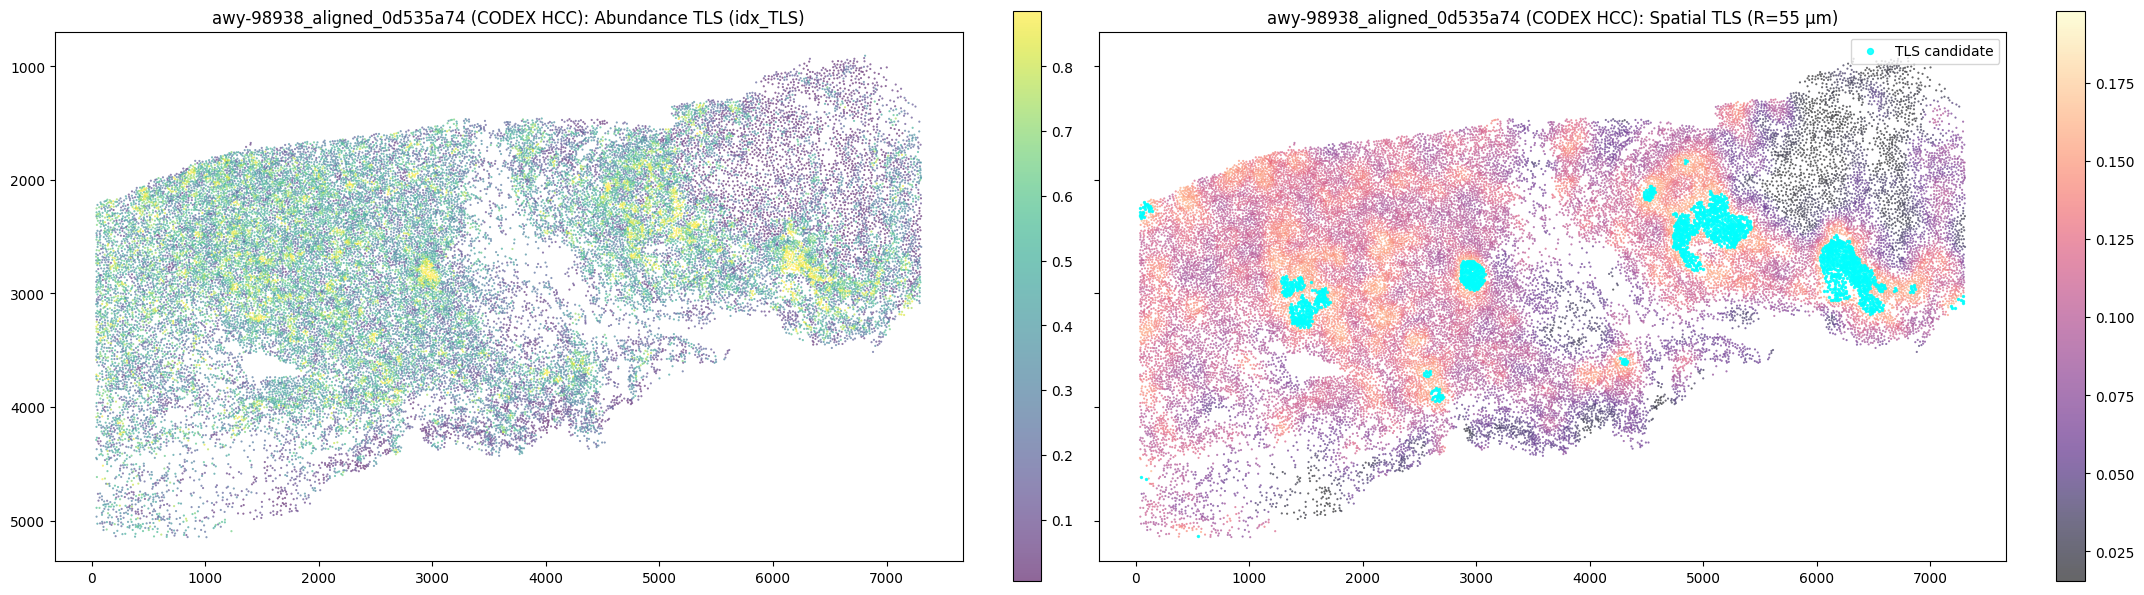

In [7]:
# TLS map
hcc_ni.plot_tls_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX HCC)",
    radius_um=RADIUS_UM,
    figsize=(18.0 * 1.2, 5.0 * 1.2),
    dpi=150,
    # save_path=str(OUT_DIR / f"{SAMPLE}_TLS_abundance_vs_spatial.jpg"),
)


## 4. Spatial SRI / TNI (stromal remodeling → active TME niche)

**Read order (increasing specificity):**

1. **SRI** — stromal remodeling: local fibroblasts vs epithelium (`Fib_local / Epi_local`).
2. **TNI** — active TME niche: co-localized fibroblasts × M2-like macrophages × endothelium, relative to epithelium.
3. **TLS** (§ above) — adaptive immune aggregate.

**Interpretation:** High SRI alone → epithelial/tumor mass replaced by stroma, but the niche may still lack M2 + endothelial co-localization. **High SRI and high TNI** → active immunosuppressive / angiogenic microenvironment.


,cell_id,coord_x,coord_y,idx_SRI_ratio,idx_SRI_spatial,idx_TNI_ratio,idx_TNI_spatial,sri_candidate,tni_candidate
32440,33159,1190.0,4585.0,399.691534,213.012998,421.202881,20.829571,True,True
32448,33168,1212.0,4592.0,184.567969,220.676314,203.106201,20.722821,True,True
32791,33538,1813.0,4917.0,224.327143,236.356437,230.674211,20.117569,True,True
32423,33139,1296.0,4573.0,118.964968,229.230986,135.193253,19.773469,True,True
32370,33081,1222.0,4531.0,145.737906,199.849570,162.396138,19.757796,True,True


Active TME-niche cells (SRI ∩ TNI hotspot): 1058 (3.21% of tissue)


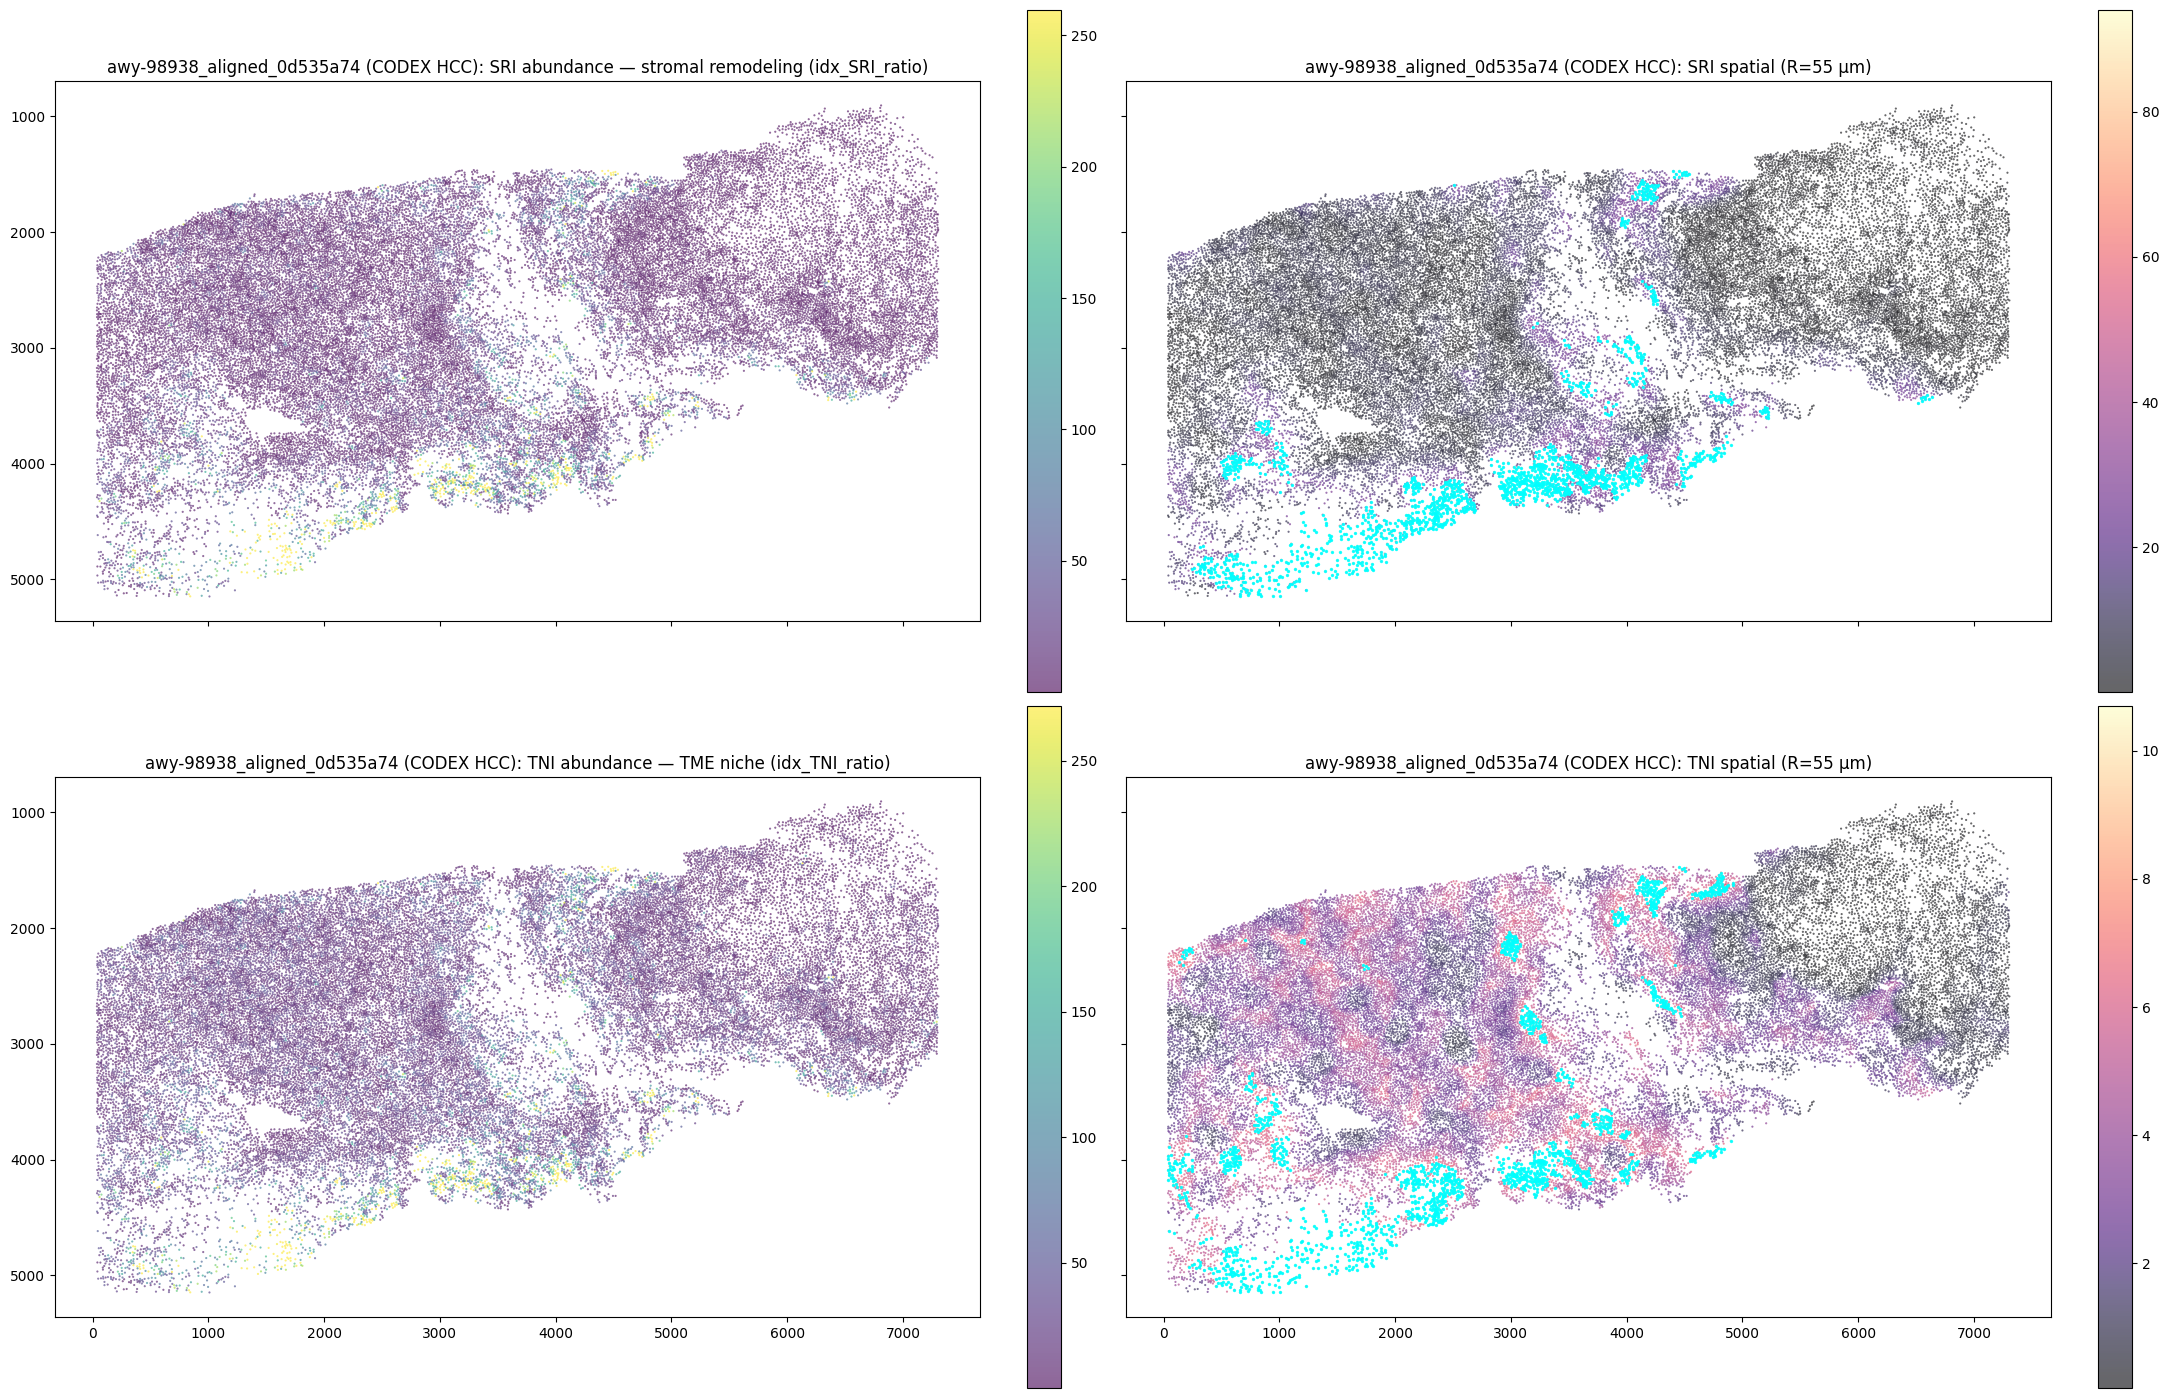

In [8]:
display(
    df_spatial[
        ["cell_id", "coord_x", "coord_y", "idx_SRI_ratio", "idx_SRI_spatial",
         "idx_TNI_ratio", "idx_TNI_spatial", "sri_candidate", "tni_candidate"]
    ]
    .sort_values("idx_TNI_spatial", ascending=False)
    .head(5)
)

hcc_ni.plot_sri_tni_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX HCC)",
    radius_um=RADIUS_UM,
    figsize=(18.0 * 1.2, 10.0 * 1.2),
    dpi=150,
    # save_path=str(OUT_DIR / f"{SAMPLE}_SRI_TNI_abundance_vs_spatial.jpg"),
)

active = df_spatial["sri_candidate"] & df_spatial["tni_candidate"]
print(
    f"Active TME-niche cells (SRI ∩ TNI hotspot): {int(active.sum())} "
    f"({100 * active.mean():.2f}% of tissue)"
)


## 5. Hierarchical SRI → TNI (within-slide quadrants)

**Not competing biomarkers:**

- **SRI** (`idx_SRI_spatial`) — broad **stromal remodeling**
- **TNI** (`idx_TNI_spatial`) — **active TME niche** embedded in remodeled tissue

Biological hierarchy: **Normal (Q1) → SRI↑ remodeling (Q2) → SRI↑+TNI↑ active niche (Q4)**.

The scatter / spatial quadrant map uses **this slide's** 95th-percentile cutoffs.  
**Cross-region clinical comparisons** use **Global Q4** and **active niche burden** in §6 — not per-slide local Q4%.

Quadrant labels are HCC-specific (SRI/TNI). The numerical procedure is the same hierarchical Q1–Q4 split used for lung ARI→FRI.


,quadrant,label,n_cells,percent
0,Q1,Normal / epithelial-dominant,30727,93.205327
1,Q2,Stromal remodeling (epithelial replacement by ...,591,1.792702
2,Q3,Immune / angiogenic activation without extensi...,591,1.792702
3,Q4,Active TME niche (fibroblasts + M2-like + endo...,1058,3.209270


Spearman rho=0.879, p=0 | Q4 (active TME niche)=3.21%


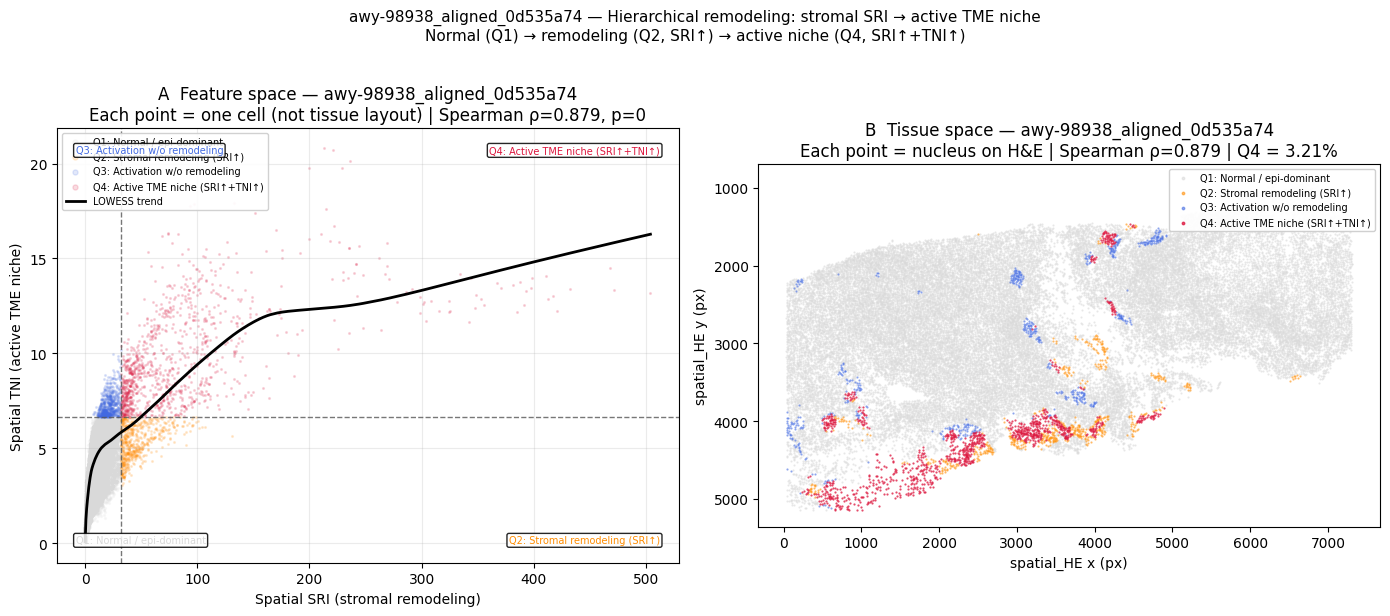

In [9]:
sri_tni_result = hcc_ni.analyze_sri_tni_relationship(
    df_spatial, SAMPLE, plot=True, plot_layout="combined",
    figsize=(14, 6),
    figsize_scatter=(5.5, 5.5),
    figsize_spatial=(8.0, 8.0),
    dpi=150,
    # save_path=str(OUT_DIR / f"{SAMPLE}_SRI_TNI_hierarchical.pdf"),
)
display(sri_tni_result["quadrant_table"])
print(
    f"Spearman rho={sri_tni_result['Spearman_rho']:.3f}, p={sri_tni_result['Spearman_p']:.2g} | "
    f"Q4 (active TME niche)={sri_tni_result['Q4_percent']:.2f}%"
)


## 6. Cohort: TME niche burden vs clinical groups

To compare **across the 36 annotated regions**, metrics must share the same cutoffs.

| Metric | Definition |
|--------|------------|
| **Global Q4 %** | % cells with `SRI_spatial ≥ SRI_global` **and** `TNI_spatial ≥ TNI_global`, where both thresholds are the **cohort-pooled 95th percentiles** |
| **Active niche burden** | `mean(√(SRI_i × TNI_i))` over all matched nuclei (no threshold) |

Clinical groups: **Response**, **diagnosis** (Pre/Post), **treatment**.  
Tests: Mann–Whitney U (2 groups) or Kruskal–Wallis (3+), `pan_organ="codex_hcc"`.

**Runtime:** `build_hcc_sample_dict` loads every region and computes BallTree neighborhoods (~30k nuclei each). Run §1–§5 first; §6 last.


In [10]:
# Cohort SRI/TNI summary (Global Q4 + active niche burden)
import importlib
importlib.reload(hcc_ni)

sample_dict = hcc_ni.build_hcc_sample_dict(
    ALL_SAMPLES,
    radius_um=RADIUS_UM,
    um_per_pixel=UM_PER_PX,
)
sri_tni_batch, cohort_meta = hcc_ni.batch_analyze_sri_tni_cohort(sample_dict)
print(
    f"Cohort global cutoffs (p{cohort_meta['percentile']:.0f}, "
    f"n={cohort_meta['n_cells_pooled']:,} cells): "
    f"SRI={cohort_meta['sri_threshold_global']:.4f}, "
    f"TNI={cohort_meta['tni_threshold_global']:.4f}"
)
display(
    sri_tni_batch.sort_values("active_niche_burden", ascending=False)[
        ["Sample", "n_cells", "Q4_global_percent", "active_niche_burden",
         "SRI_median", "TNI_median", "Spearman_rho"]
    ].head()
)


  loaded awy-98938_aligned_0d535a74: 32,967 cells
  loaded awy-98938_aligned_59f27598: 32,333 cells
  loaded awy-98938_aligned_8ded610e: 12,262 cells
  loaded awy-98938_aligned_a5afeef9: 42,174 cells
  loaded dpn-56105_aligned_85543451: 25,780 cells
  loaded dpn-56105_aligned_b32cf147: 15,636 cells
  loaded dpn-56105_aligned_d24763ad: 13,120 cells
  loaded fcu-91631_aligned_1e3c06f5: 34,185 cells
  loaded fcu-91631_aligned_2e321bd1: 8,045 cells
  loaded fcu-91631_aligned_4722207f: 25,892 cells
  loaded fcu-91631_aligned_7ffa2d5a: 17,129 cells
  loaded kqr-83230_aligned_3bba12d6: 40,788 cells
  loaded kqr-83230_aligned_5b50bc37: 24,203 cells
  loaded kqr-83230_aligned_6f5021e3: 15,247 cells
  loaded kqr-83230_aligned_b24a3fb5: 32,882 cells
  loaded lvr-76315_aligned_5c66cd56: 21,332 cells
  loaded lvr-76315_aligned_7c2e2f0a: 43,817 cells
  loaded lvr-76315_aligned_9c96ea90: 42,821 cells
  loaded nwn-95916_aligned_459f2ffd: 48,416 cells
  loaded nwn-95916_aligned_737dafc9: 49,827 cells
 

,Sample,n_cells,Q4_global_percent,active_niche_burden,SRI_median,TNI_median,Spearman_rho
21,nwn-95916_aligned_d1ec33a2,8479,35.900460,7.716075,8.714762,4.292547,0.967328
35,xid-87175_aligned_c06f7c7e,38192,22.834625,6.978715,7.101783,5.036884,0.940562
3,awy-98938_aligned_a5afeef9,42174,19.656661,6.350988,5.943122,3.368592,0.956004
0,awy-98938_aligned_0d535a74,32967,8.147541,4.968835,4.076764,3.051816,0.879056
25,ovn-46364_aligned_cb1fb28a,49040,14.898042,4.290819,2.707744,2.081551,0.986568


=== Global Q4 % (cohort SRI/TNI cutoffs) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,Q4_global_percent,rank,Mann-Whitney U,0.006252,248.0,2,"[Responder, Non_Responder]","[0.7610073284096567, 0.008023118009756448]","[0.7610073284096567, 0.008023118009756448]",2.204014
1,diagnosis,Q4_global_percent,rank,Mann-Whitney U,0.433328,137.0,2,"[Pre, Post]","[0.2108752971936688, 0.5027017514230044]","[0.2108752971936688, 0.5027017514230044]",0.363183
2,treatment,Q4_global_percent,rank,Mann-Whitney U,0.882658,149.0,2,"[List A, List B]","[0.355766535141123, 0.2590338170399283]","[0.355766535141123, 0.2590338170399283]",0.054208


=== Active TME niche burden mean(√SRI×TNI) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,active_niche_burden,rank,Mann-Whitney U,0.007507,247.0,2,"[Responder, Non_Responder]","[1.5809448243008801, 0.5073739796822243]","[1.5809448243008801, 0.5073739796822243]",2.124517
1,diagnosis,active_niche_burden,rank,Mann-Whitney U,0.516603,141.0,2,"[Pre, Post]","[0.6581253280123558, 0.8215436748967127]","[0.6581253280123558, 0.8215436748967127]",0.286843
2,treatment,active_niche_burden,rank,Mann-Whitney U,0.782683,145.0,2,"[List A, List B]","[0.6581253280123558, 1.316671219573062]","[0.6581253280123558, 1.316671219573062]",0.106414


(<Figure size 1200x400 with 3 Axes>,
 array([[<Axes: title={'center': 'Response'}, ylabel='Active TME niche burden'>,
         <Axes: title={'center': 'diagnosis'}>,
         <Axes: title={'center': 'treatment'}>]], dtype=object))

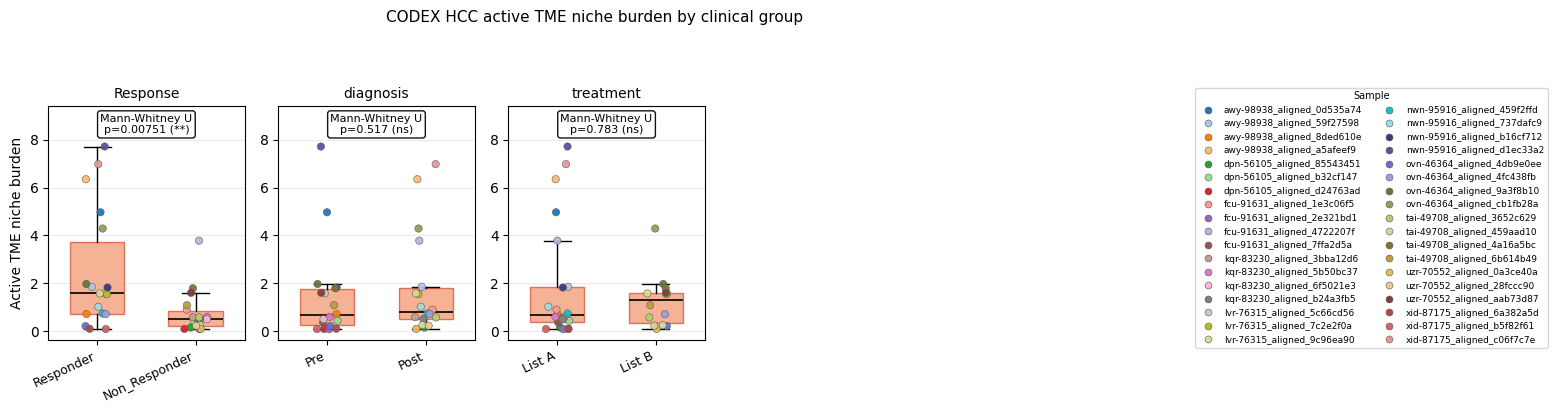

In [11]:
# Main results: Global Q4 % and active niche burden vs HCC clinical groups
sri_tni_clinical = hcc_ni.merge_batch_with_hcc_clinical(sri_tni_batch, clinical)

q4_stats = hcc_ni.test_hcc_clinical_groups(
    sri_tni_clinical, metric_col="Q4_global_percent", alternative="two-sided",
)
burden_stats = hcc_ni.test_hcc_clinical_groups(
    sri_tni_clinical, metric_col="active_niche_burden", alternative="two-sided",
)
print("=== Global Q4 % (cohort SRI/TNI cutoffs) ===")
display(q4_stats)
print("=== Active TME niche burden mean(√SRI×TNI) ===")
display(burden_stats)

# hcc_ni.plot_hcc_clinical_comparison(
#     sri_tni_clinical, q4_stats,
#     q4_col="Q4_global_percent",
#     figsize=(12, 4),
#     legend_ncol=2,
#     ylabel="Global Q4 % (cohort SRI/TNI cutoffs)",
#     suptitle="CODEX HCC Global Q4 % by clinical group",
#     # save_path=str(OUT_DIR / "cohort_global_q4_clinical_comparison.pdf"),
# )

hcc_ni.plot_hcc_clinical_comparison(
    sri_tni_clinical, burden_stats,
    q4_col="active_niche_burden",
    figsize=(12, 4),
    legend_ncol=2,
    ylabel="Active TME niche burden",
    suptitle="CODEX HCC active TME niche burden by clinical group",
    # save_path=str(OUT_DIR / "cohort_active_tme_niche_burden_clinical_comparison.pdf"),
)


## 7. Patient-level Response and source decomposition

§6 treats each HE region as independent. Most patients contribute 3–4 regions, so the Responder vs Non-responder p-value can be anti-conservative.

This section:

1. Computes region-level **SRI_mean**, **TNI_mean**, **Epi_local_mean**, and **TNI_numerator_mean** (`(Fib×M2×Endo)^(1/3)`, no epithelium in the denominator).
2. Tests Response on those metrics at **region** level (same pseudo-replication as §6).
3. Averages metrics within `patient_id` (equal weight per slide) and re-tests Response.
4. Plots SRI-only, TNI-only, Epi_local, and the TNI numerator side by side.

**How to read it**

| Pattern | Interpretation |
|---------|----------------|
| SRI/TNI significant, **Epi_local lower** in Responders, numerator ns | Ratio inflation from low epithelium |
| Numerator (and/or Fib/M2/Endo) significant, Epi similar | Niche colocalization, not just epithelial loss |
| Region p small, **patient p ns** | Association does not survive collapsing pseudo-replicates |

Requires `sample_dict` from §6 (no reload). Epi is reconstructed from `Fib_local / SRI` if `idx_Epi_local` was not saved.

In [14]:
# Region-level source metrics (from sample_dict already loaded in §6)
import importlib
importlib.reload(hcc_ni)

source = hcc_ni.summarize_hcc_source_metrics(sample_dict)
region_source = sri_tni_clinical.merge(
    source.drop(columns=["n_cells"], errors="ignore"),
    on="Sample",
    how="left",
)
print(
    "Regions:", len(region_source),
    "| patients:", region_source["patient_id"].nunique(),
)
print(region_source.groupby("Response")["patient_id"].nunique())
display(
    region_source[
        ["Sample", "patient_id", "Response", "SRI_mean", "TNI_mean",
         "Epi_local_mean", "TNI_numerator_mean", "active_niche_burden"]
    ].head()
)

region_source_stats = hcc_ni.test_hcc_response_source_metrics(region_source)
print("=== Region-level Response (pseudo-replicated) ===")
display(region_source_stats)

patient_source = hcc_ni.aggregate_hcc_metrics_by_patient(region_source)
patient_source_stats = hcc_ni.test_hcc_response_source_metrics(patient_source)
print("=== Patient-level Response (mean of regions) ===")
display(patient_source[["patient_id", "n_regions", "Response", "SRI_mean", "TNI_mean",
                        "Epi_local_mean", "TNI_numerator_mean", "active_niche_burden"]])
display(patient_source_stats)


Regions: 36 | patients: 10
Response
Non_Responder    5
Responder        5
Name: patient_id, dtype: int64


,Sample,patient_id,Response,SRI_mean,TNI_mean,Epi_local_mean,TNI_numerator_mean,active_niche_burden
0,awy-98938_aligned_0d535a74,85557,Responder,9.321481,3.205450,0.068297,0.061445,4.968835
1,awy-98938_aligned_59f27598,85557,Responder,2.350408,1.527090,0.104516,0.080355,1.857430
2,awy-98938_aligned_8ded610e,85557,Responder,0.939602,0.609951,0.399248,0.055454,0.716380
3,awy-98938_aligned_a5afeef9,85557,Responder,10.242388,4.152444,0.035101,0.066362,6.350988
4,dpn-56105_aligned_85543451,85559,Non_Responder,0.166345,0.159820,0.543760,0.052788,0.156189


=== Region-level Response (pseudo-replicated) ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,SRI_mean,rank,Mann-Whitney U,0.008246,246.0,2,"[Responder, Non_Responder]","[2.2165393802674584, 0.5990918227618623]","[2.2165393802674584, 0.5990918227618623]",2.083751
1,Response,TNI_mean,rank,Mann-Whitney U,0.007507,247.0,2,"[Responder, Non_Responder]","[1.2236723234856601, 0.44976045187859126]","[1.2236723234856601, 0.44976045187859126]",2.124517
2,Response,Epi_local_mean,rank,Mann-Whitney U,0.013005,83.0,2,"[Responder, Non_Responder]","[0.19145744894445788, 0.3813924920724626]","[0.19145744894445788, 0.3813924920724626]",1.885887
3,Response,TNI_numerator_mean,rank,Mann-Whitney U,0.261365,198.0,2,"[Responder, Non_Responder]","[0.06649199534584417, 0.059577337044375706]","[0.06649199534584417, 0.059577337044375706]",0.582752


  warn: patient_id=85557 has mixed diagnosis=['Pre', 'Post']; using Pre
  warn: patient_id=85558 has mixed diagnosis=['Post', 'Pre']; using Post
  warn: patient_id=85559 has mixed diagnosis=['Post', 'Pre']; using Post
  warn: patient_id=85560 has mixed diagnosis=['Post', 'Pre']; using Post
  warn: patient_id=85561 has mixed diagnosis=['Post', 'Pre']; using Post
  warn: patient_id=85562 has mixed diagnosis=['Pre', 'Post']; using Pre
  warn: patient_id=85566 has mixed diagnosis=['Pre', 'Post']; using Pre
  warn: patient_id=85567 has mixed diagnosis=['Pre', 'Post']; using Pre
  warn: patient_id=85568 has mixed diagnosis=['Post', 'Pre']; using Post
  warn: patient_id=85569 has mixed diagnosis=['Post', 'Pre']; using Post
=== Patient-level Response (mean of regions) ===


,patient_id,n_regions,Response,SRI_mean,TNI_mean,Epi_local_mean,TNI_numerator_mean,active_niche_burden
0,85557,4,Responder,5.713470,2.373734,0.151790,0.065904,3.473408
1,85558,4,Responder,4.320957,1.966768,0.208980,0.097192,2.827068
2,85559,3,Non_Responder,0.273560,0.213712,0.502634,0.048794,0.230926
3,85560,4,Non_Responder,0.656502,0.485899,0.279331,0.062216,0.550921
4,85561,4,Non_Responder,2.069827,0.854006,0.467061,0.059783,1.286029
5,85562,3,Responder,3.064392,1.919764,0.372616,0.038742,2.391789
6,85566,3,Responder,2.258696,1.195621,0.190381,0.076647,1.569214
7,85567,4,Responder,2.602241,1.324945,0.318242,0.046249,1.799210
8,85568,3,Non_Responder,0.844548,0.554884,0.369589,0.054277,0.645811
9,85569,4,Non_Responder,1.101664,0.815714,0.312605,0.062443,0.928545


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Response,SRI_mean,rank,Mann-Whitney U,0.007937,25.0,2,"[Responder, Non_Responder]","[3.064391941117993, 0.8445480280496369]","[3.064391941117993, 0.8445480280496369]",2.100371
1,Response,TNI_mean,rank,Mann-Whitney U,0.007937,25.0,2,"[Responder, Non_Responder]","[1.9197642351751785, 0.5548838588490574]","[1.9197642351751785, 0.5548838588490574]",2.100371
2,Response,Epi_local_mean,rank,Mann-Whitney U,0.150794,5.0,2,"[Responder, Non_Responder]","[0.20897955820022063, 0.36958943045253384]","[0.20897955820022063, 0.36958943045253384]",0.821617
3,Response,TNI_numerator_mean,rank,Mann-Whitney U,0.690476,15.0,2,"[Responder, Non_Responder]","[0.06590408928673713, 0.059783417249041945]","[0.06590408928673713, 0.059783417249041945]",0.160851


In [ ]:
# Response boxplots: SRI / TNI / Epi_local / TNI numerator
hcc_ni.plot_hcc_response_source_grid(
    region_source, region_source_stats,
    sample_col="patient_id",
    suptitle="Region-level (points colored by patient) — same pseudo-replication as §6",
)

hcc_ni.plot_hcc_response_source_grid(
    patient_source, patient_source_stats,
    sample_col="patient_id",
    suptitle="Patient-level (one point per patient; unweighted mean of that patient's regions)",
)

(<Figure size 1680x460 with 4 Axes>,
 array([[<Axes: title={'center': 'SRI (Fib / Epi)'}, ylabel='region or patient mean'>,
         <Axes: title={'center': 'TNI (geomean / Epi)'}>,
         <Axes: title={'center': 'Epi_local (neighborhood epithelium)'}>,
         <Axes: title={'center': 'TNI numerator (Fib×M2×Endo geomean)'}>]],
       dtype=object))